# 재정대응지수 구축 및 재정반응성 기초분석

- 작성자: 이정연
- 관련 이슈: #62
- 분석 단위: 17개 시도 × 2016~2024년 × 세부영역 11개(+ "지표체계 외" 1개)
- 범위: 세부영역별 인구1인당 실질예산액(F_it) 산출과 재정반응성 모형 A(보완 분석) 재현

2026-08-07 팀 결정에 따라 지역×연도 단위 총액 기준 단일 지수(이전 초안)를 세부영역별 지수로 교체했다. 계산 로직은 `scripts/*.py`·`src/features/analysis_panel.py`·`src/modeling/fiscal_response.py`의 기존 함수를 그대로 호출하며, 이 노트북은 재현·QA 전용이다. 주분석(모형 C, TFR ~ F_i,t-1)은 #98에서 별도로 다룬다.

## 분석 배경과 방법

세부영역(11개)별로 인구1인당 실질예산액을 산출하고, 직전 연도 출산율 하락도(ΔTFR_i,t-1)에 대한 재정반응성을 지역·연도 고정효과 모형(모형 A, 기본모형)으로 추정한다.

### 주요 가정(2026-08-07 팀 결정 + 이 파이프라인의 모형화 판단)

- 예산은 CPI 2024=100 기준으로 실질화한다.
- 인구 분모는 **전체인구 1인당이 주 기준**(제주도 방식), 20~39세 1인당은 참고용 민감도 계열이다.
- 세부영역별 재정대응지수(z-score)는 **세부영역 내부에서만** pooled z-score로 표준화한다(영역 간 스케일 혼합 방지).
- 회귀분석에는 지수(z-score)가 아니라 **인구1인당 예산액 자체**를 쓴다(팀 결정). 다만 세부영역 간 스케일이 1만 배 이상 차이 나 **log1p 변환**을 적용한다 — 이건 팀 결정문이 아니라 이 파이프라인이 내린 모형화 판단이다.
- 출산동향(ΔTFR_i,t-1)과 구조환경지수(S_i,t-1)는 모두 예산편성 이전 1년 시차 값만 쓴다.
- "지표체계 외"(중장년·신중년 단일대상 사업)는 재정대응지수·회귀 대상에서 제외한다.

### 1. 분석 환경 설정

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

installed_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font_candidates = ("AppleGothic", "Malgun Gothic", "NanumGothic")
KOREAN_FONT = next(
    (font for font in korean_font_candidates if font in installed_fonts),
    "sans-serif",
)
plt.rcParams.update({"font.family": KOREAN_FONT, "axes.unicode_minus": False})

np.random.seed(42)

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    path for path in (current_dir, *current_dir.parents) if (path / "pyproject.toml").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SUB_AREA_PANEL_PATH = PROJECT_ROOT / "data/interim/provisional/provisional_sub_area_panel.csv"
CPI_PATH = PROJECT_ROOT / "data/lookup/연도별_소비자물가지수_2024기준.csv"
REGION_MAP_PATH = PROJECT_ROOT / "data/lookup/시도_지역코드_매핑.csv"
FERTILITY_PATH = (
    PROJECT_ROOT / "data/raw/출산동향/2016-2025_시도별_출생아수_합계출산율_20260703.csv"
)
STRUCTURAL_SUBCATEGORY_PATH = (
    PROJECT_ROOT / "data/processed/structural_index/structural_index_pooled_subcategory_scores.csv"
)
FISCAL_RESPONSE_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_세부영역별_인구1인당_실질예산액.csv"
)
FISCAL_INDEX_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_세부영역별_재정대응지수.csv"
)
REGRESSION_SAMPLE_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_세부영역별_재정반응성_회귀표본.csv"
)
MODEL_RESULT_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_세부영역별_재정반응성_고정효과_결과.csv"
)
SENSITIVITY_OUTPUT_PATH = (
    PROJECT_ROOT / "data/processed/analysis/2016-2024_세부영역별_재정반응성_인구분모_민감도비교.csv"
)

from scripts.build_subarea_fiscal_response_variable import (  # noqa: E402
    DEFAULT_POPULATION_PATH,
    build_subarea_response_variable,
    load_total_population,
)
from scripts.build_subarea_fiscal_response_regression_sample import (  # noqa: E402
    FISCAL_TO_STRUCTURAL_SUBCATEGORY,
    build_lagged_structural_index,
    build_regression_sample,
)
from scripts.run_subarea_fiscal_responsiveness_regression import run_subarea_models  # noqa: E402
from scripts.compare_subarea_population_denominator_sensitivity import (  # noqa: E402
    DENOMINATOR_LABELS,
    build_comparison_table,
    build_regression_sample_for_denominator,
)
from src.features.analysis_panel import (  # noqa: E402
    add_fiscal_response_features,
    add_subarea_fiscal_index_features,
    load_fertility_panel,
)
from src.visualization.trends import (  # noqa: E402
    plot_fiscal_response_overview,
    plot_fiscal_response_subarea_small_multiples,
)

POPULATION_PATH = DEFAULT_POPULATION_PATH
SUBAREA_ORDER = list(FISCAL_TO_STRUCTURAL_SUBCATEGORY)
START_YEAR = 2016
END_YEAR = 2024
EXPECTED_REGIONS = 17
EXPECTED_SUBAREAS = 11

print(f"프로젝트 경로: {PROJECT_ROOT}")
print(f"그래프 한글 글꼴: {KOREAN_FONT}")

프로젝트 경로: /Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha
그래프 한글 글꼴: AppleGothic


## 데이터

### 2. 입력 데이터 불러오기 및 검증

In [2]:
sub_area_panel = pd.read_csv(SUB_AREA_PANEL_PATH)
cpi = pd.read_csv(CPI_PATH, encoding="utf-8-sig")
region_map = pd.read_csv(REGION_MAP_PATH)

display(sub_area_panel.head(3))
display(cpi[["연도", "소비자물가지수", "기준연도"]])
print("세부영역 예산 패널 shape:", sub_area_panel.shape)

assert sub_area_panel["세부영역"].nunique() == EXPECTED_SUBAREAS + 1  # "지표체계 외" 포함
assert sub_area_panel["지역"].nunique() == EXPECTED_REGIONS
assert len(sub_area_panel) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1) * (
    EXPECTED_SUBAREAS + 1
)
assert cpi["연도"].tolist() == list(range(START_YEAR, END_YEAR + 1))
assert cpi["기준연도"].nunique() == 1 and cpi["기준연도"].iloc[0] == "2024=100"

input_qa = pd.Series(
    {
        "관측치": len(sub_area_panel),
        "지역수": sub_area_panel["지역"].nunique(),
        "연도수": sub_area_panel["연도"].nunique(),
        "세부영역수(지표체계 외 포함)": sub_area_panel["세부영역"].nunique(),
        "예산결측_사업수_합": int(sub_area_panel["예산결측_사업수"].sum()),
    },
    name="값",
)
display(input_qa.to_frame())

,지역,연도,세부영역,당해계획예산_백만원_provisional,사업수,예산결측_사업수
0,강원,2016,1-1. 고용여건,"2,743.0000",2,0
1,강원,2016,1-2. 주거안정성,0.0000,0,0
2,강원,2016,1-3. 경제적 여건,"5,129.0000",23,1


,연도,소비자물가지수,기준연도
0,2016,83.7868,2024=100
1,2017,85.3396,2024=100
2,2018,86.7980,2024=100
3,2019,87.0685,2024=100
4,2020,87.5350,2024=100
5,2021,89.8022,2024=100
6,2022,94.5903,2024=100
7,2023,97.7066,2024=100
8,2024,100.0000,2024=100


세부영역 예산 패널 shape: (1836, 6)


,값
관측치,1836
지역수,17
연도수,9
세부영역수(지표체계 외 포함),12
예산결측_사업수_합,287


### 3. 인구 패널 생성(전체인구 주 기준)

20~39세 1인당 계열은 8절 민감도 분석에서 별도로 만든다.

In [3]:
population = load_total_population(POPULATION_PATH, REGION_MAP_PATH)

assert len(population) == EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1)
assert population["전체인구_명"].gt(0).all()

display(population.head())
display(
    population.groupby("연도", as_index=False)["전체인구_명"]
    .sum()
    .rename(columns={"전체인구_명": "전국_전체인구_명"})
)

,지역,연도,전체인구_명
0,강원,2016,1550806
1,강원,2017,1550142
2,강원,2018,1543052
3,강원,2019,1541502
4,강원,2020,1542840


,연도,전국_전체인구_명
0,2016,51696216
1,2017,51778544
2,2018,51826059
3,2019,51849861
4,2020,51829023
5,2021,51638809
6,2022,51439038
7,2023,51325329
8,2024,51217221


### 4. 세부영역별 인구1인당 실질예산액(F_it) 및 재정대응지수 산출

F_it은 예산 실질화(CPI 2024=100) 후 전체인구로 나눈 값이다. 재정대응지수(z-score, 0~100점)는 회귀에는 쓰지 않지만 지수 자체의 지역·연도 비교용으로 같이 산출한다(#62 팀 결정).

In [4]:
fiscal_response = build_subarea_response_variable(sub_area_panel, cpi, population)

expected_rows = EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1) * (EXPECTED_SUBAREAS + 1)
assert len(fiscal_response) == expected_rows
assert np.isfinite(fiscal_response["인구1인당_실질예산_원"]).all()

# "지표체계 외"는 정책 영역이 아니라 잔여 범주라 지수·회귀 대상에서 뺀다.
indexable = fiscal_response.loc[fiscal_response["세부영역"].ne("지표체계 외")].copy()
fiscal_index = add_subarea_fiscal_index_features(indexable)

assert fiscal_index["세부영역"].nunique() == EXPECTED_SUBAREAS
for _, group in fiscal_index.groupby("세부영역"):
    assert np.isclose(group["세부영역_재정대응지수_z"].mean(), 0.0, atol=1e-9)
    assert np.isclose(group["세부영역_재정대응지수_z"].std(ddof=0), 1.0, atol=1e-9)

# 산출물 스크립트가 이미 저장해둔 CSV와 일치하는지 확인 — 재현성 검증.
if FISCAL_RESPONSE_OUTPUT_PATH.exists():
    persisted_fiscal_response = pd.read_csv(FISCAL_RESPONSE_OUTPUT_PATH)
    pd.testing.assert_frame_equal(
        fiscal_response.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        persisted_fiscal_response.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        check_dtype=False,
    )
    print("저장된 F_it CSV와 노트북 재계산 결과 일치 확인")
if FISCAL_INDEX_OUTPUT_PATH.exists():
    persisted_fiscal_index = pd.read_csv(FISCAL_INDEX_OUTPUT_PATH)
    pd.testing.assert_frame_equal(
        fiscal_index.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        persisted_fiscal_index.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        check_dtype=False,
        atol=1e-6,
    )
    print("저장된 재정대응지수 CSV와 노트북 재계산 결과 일치 확인")

display(
    fiscal_index[
        [
            "지역",
            "연도",
            "세부영역",
            "인구1인당_실질예산_원",
            "세부영역_재정대응지수_z",
            "세부영역_재정대응점수_0_100",
        ]
    ].head(10)
)

저장된 F_it CSV와 노트북 재계산 결과 일치 확인


저장된 재정대응지수 CSV와 노트북 재계산 결과 일치 확인


,지역,연도,세부영역,인구1인당_실질예산_원,세부영역_재정대응지수_z,세부영역_재정대응점수_0_100
0,강원,2016,1-1. 고용여건,"2,111.0227",-0.6084,68.5286
1,강원,2017,1-1. 고용여건,"5,883.3510",-0.0229,77.7010
2,강원,2018,1-1. 고용여건,0.0000,-4.9828,0.0000
3,강원,2019,1-1. 고용여건,"45,715.0502",1.1486,96.0533
4,강원,2020,1-1. 고용여건,"15,496.9340",0.5305,86.3699
5,강원,2021,1-1. 고용여건,"33,337.4538",0.9682,93.2269
6,강원,2022,1-1. 고용여건,"34,568.4870",0.9889,93.5515
7,강원,2023,1-1. 고용여건,"20,790.9064",0.6984,89.0004
8,강원,2024,1-1. 고용여건,"13,323.5295",0.4441,85.0173
9,강원,2016,1-2. 주거안정성,0.0000,-2.1430,0.0000


## 분석 결과

### 5. 분포·추세 확인(로그축)

/Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/src/visualization/trends.py:312: UserWarning: 인구1인당_실질예산_원에 0인 값이 104건 있습니다 — 로그축에서는 표시되지 않습니다.
  _check_log_axis_values(data["인구1인당_실질예산_원"], label="인구1인당_실질예산_원")


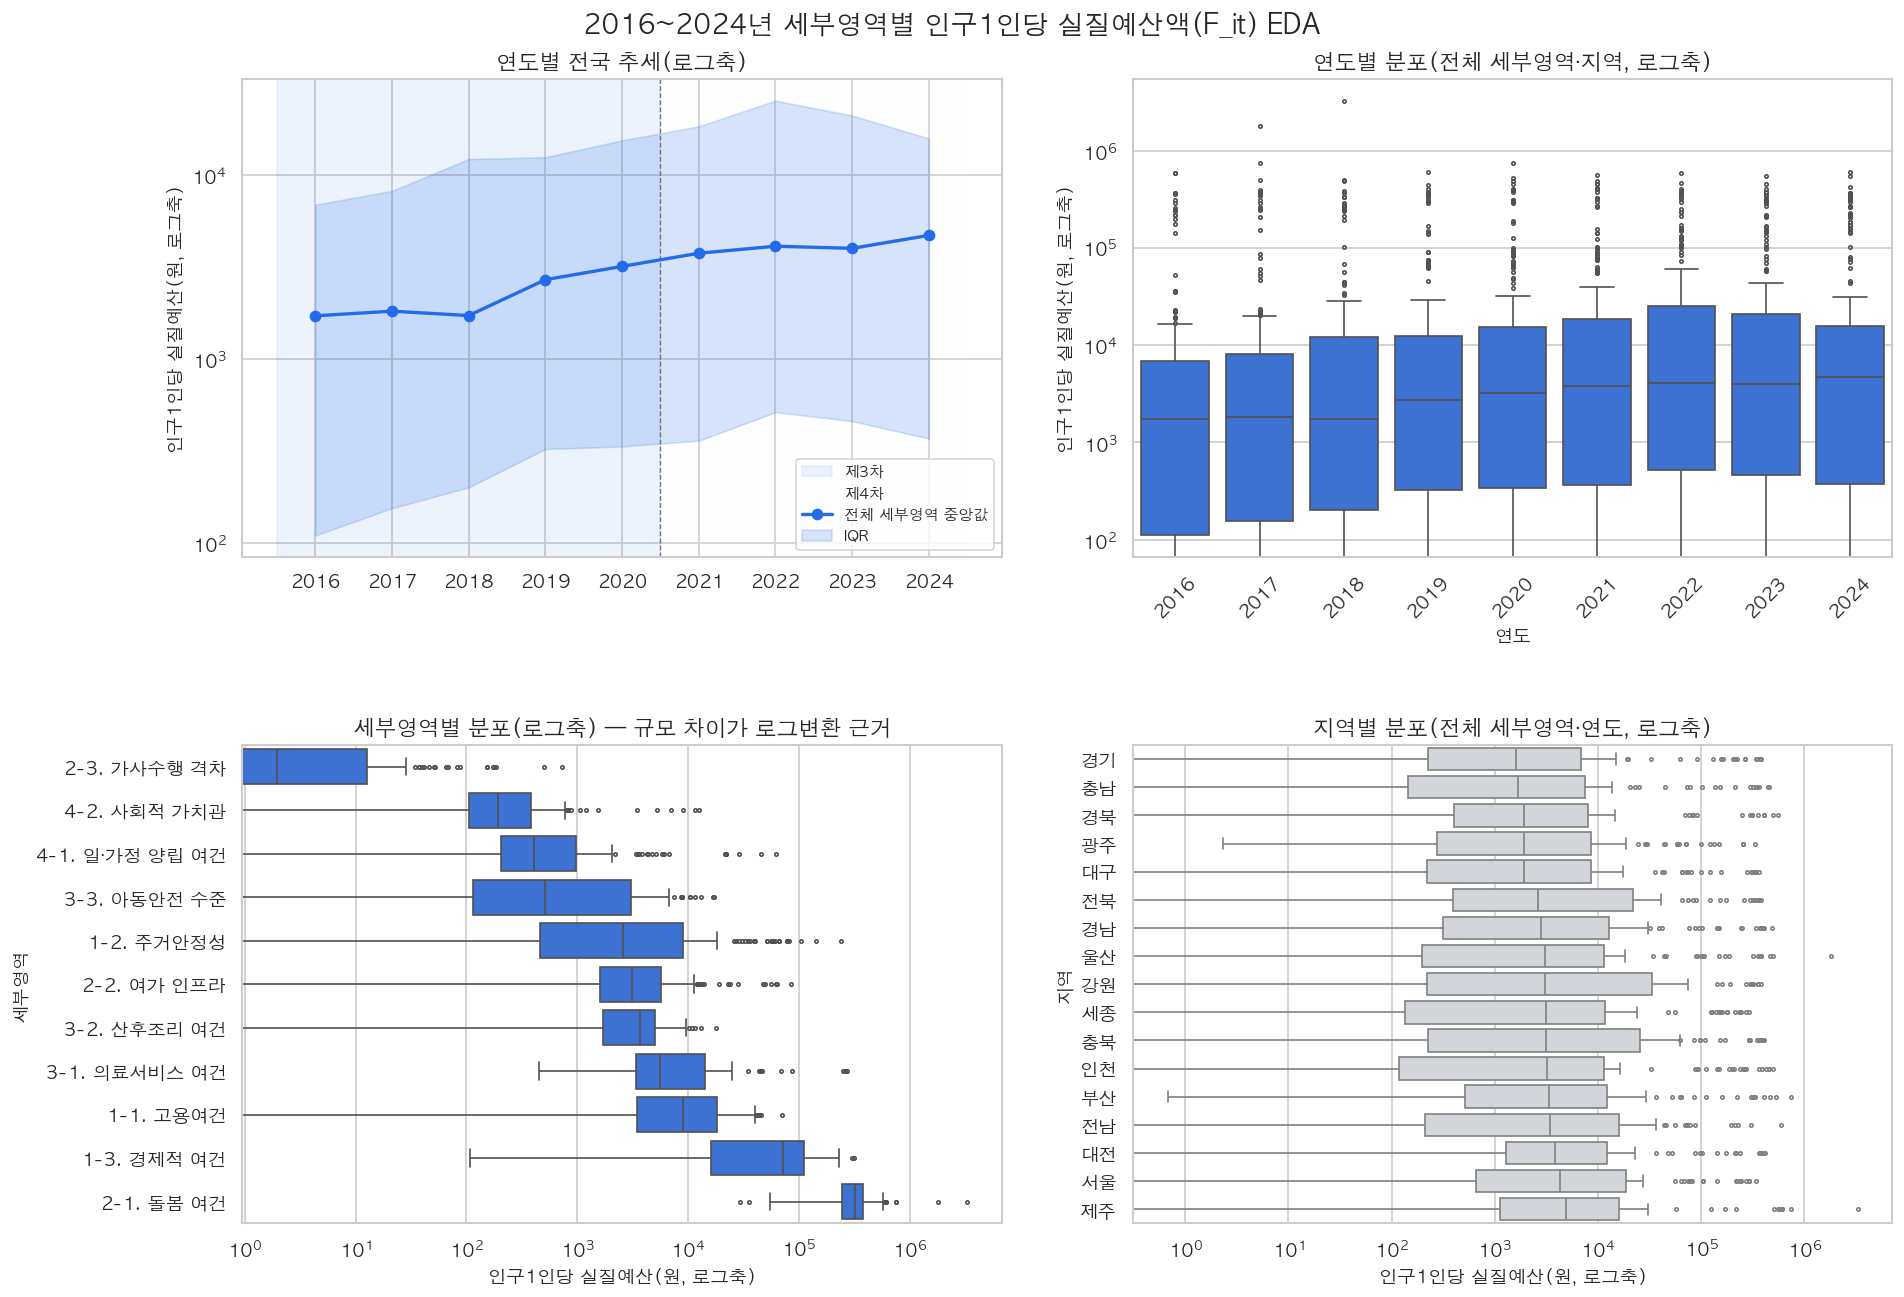

In [5]:
fig = plot_fiscal_response_overview(indexable)
plt.show()

/Users/leejungyeon/Workspace/projects/한국재정정보원/yumocha/src/visualization/trends.py:394: UserWarning: 인구1인당_실질예산_원에 0인 값이 104건 있습니다 — 로그축에서는 표시되지 않습니다.
  _check_log_axis_values(


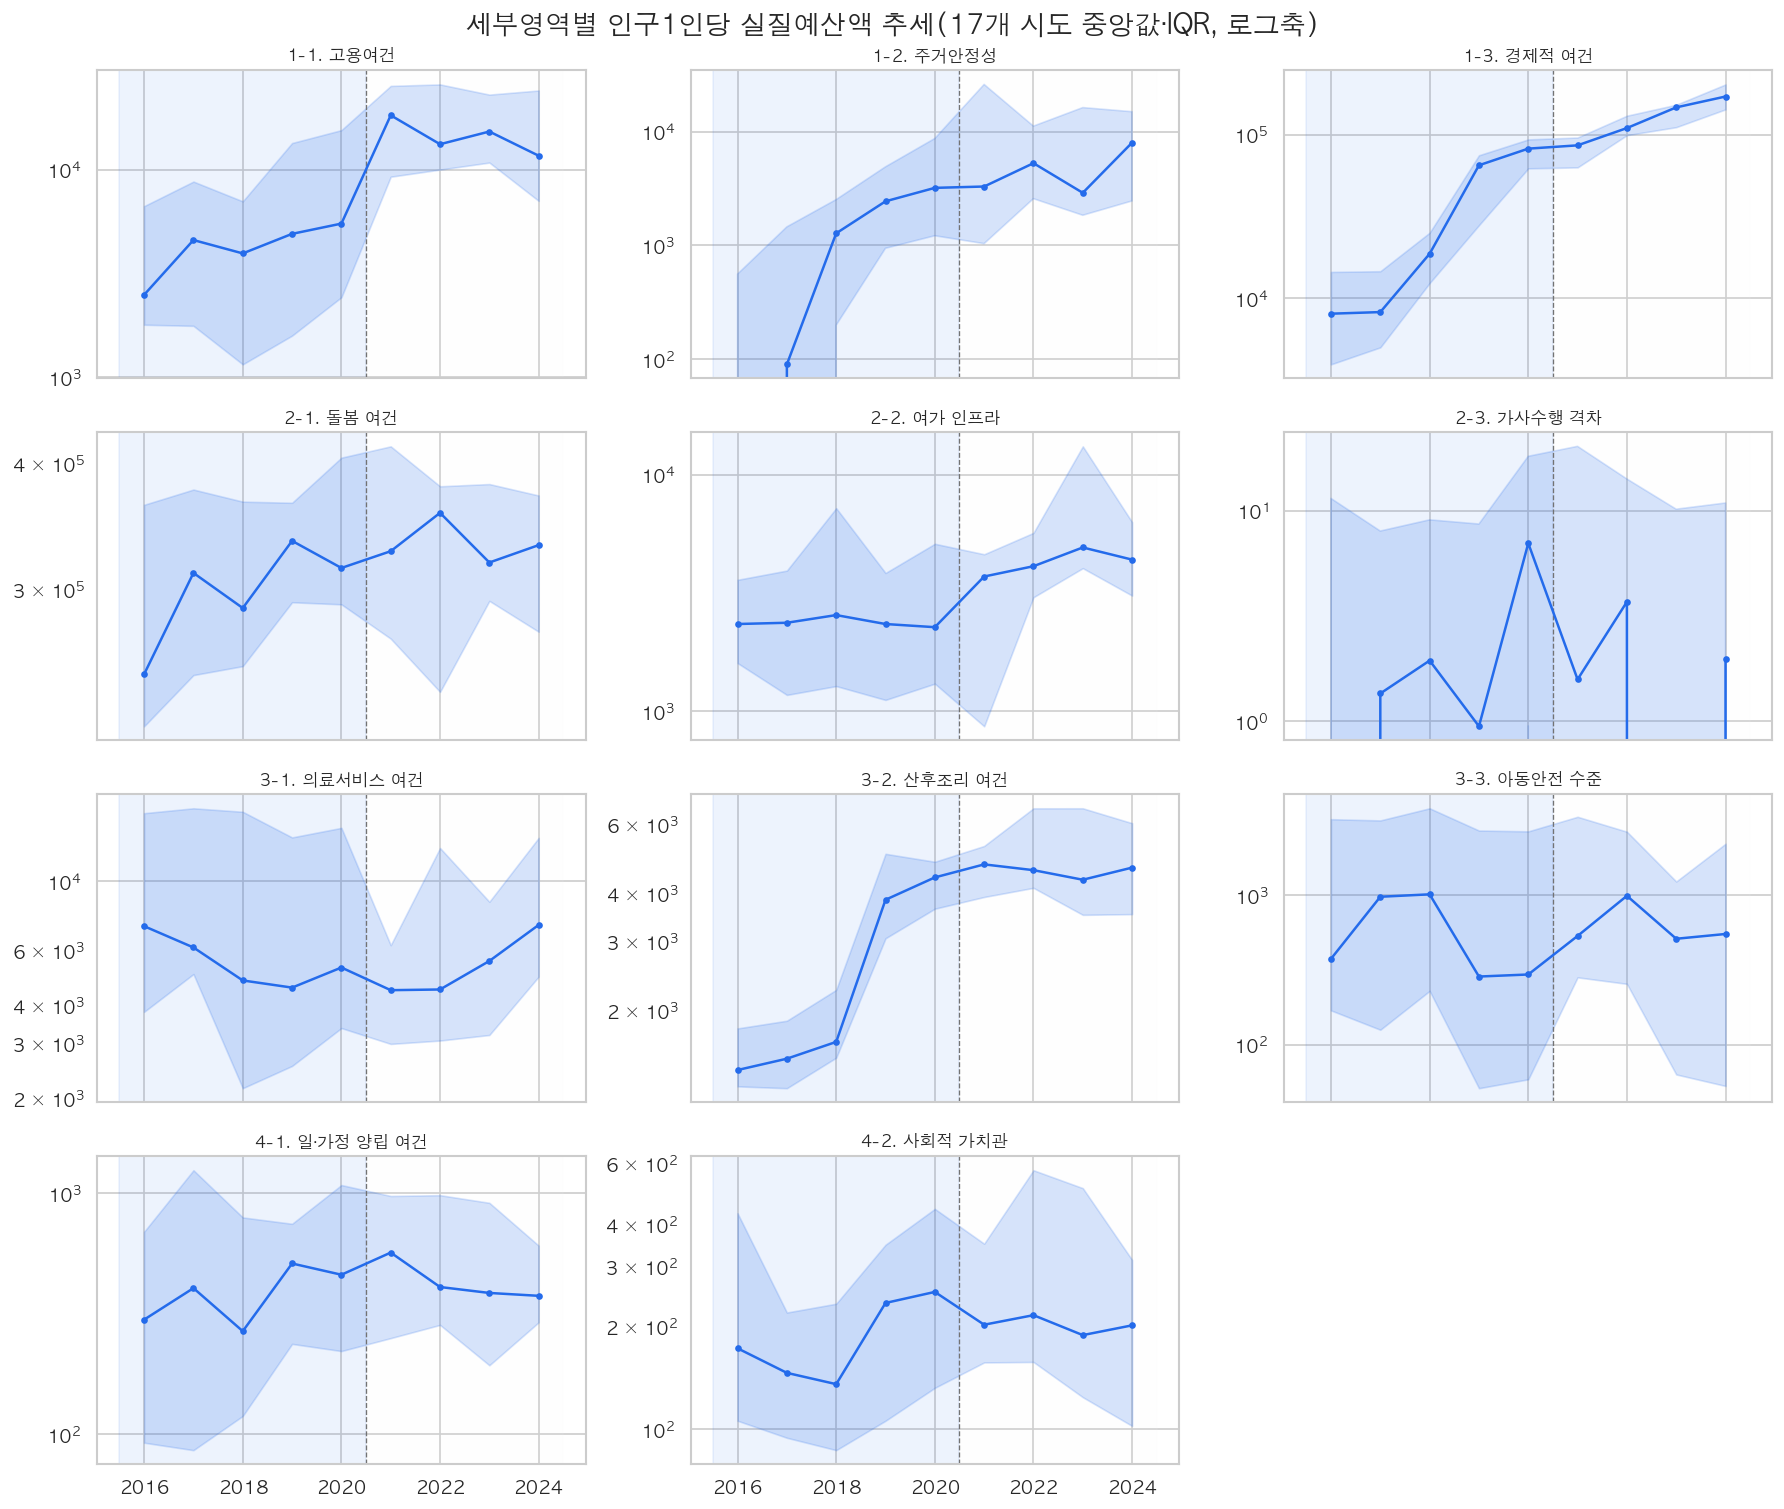

In [6]:
fig = plot_fiscal_response_subarea_small_multiples(indexable, subarea_order=SUBAREA_ORDER)
plt.show()

### 6. 회귀표본 구성(F_it, ΔTFR_i,t-1, S_i,t-1)

직전 1년 출산율 하락도(`add_fiscal_response_features`)와 같은 세부영역의 전년도 구조환경지수(`build_lagged_structural_index`)를 F_it에 결합한다. 구조환경지수는 이 노트북의 모형 A(기본모형)에는 쓰지 않지만, 통제변수 추가판을 만들 때 바로 쓸 수 있도록 표본에 같이 둔다.

In [7]:
fertility_panel, _ = load_fertility_panel(
    FERTILITY_PATH, REGION_MAP_PATH, expected_years=list(range(START_YEAR, END_YEAR + 1))
)
fertility_lagged = add_fiscal_response_features(fertility_panel)

structural_scores = pd.read_csv(STRUCTURAL_SUBCATEGORY_PATH)
structural_lagged = build_lagged_structural_index(structural_scores)

regression_sample = build_regression_sample(fiscal_response, fertility_lagged, structural_lagged)

expected_sample_rows = EXPECTED_REGIONS * (END_YEAR - START_YEAR + 1) * EXPECTED_SUBAREAS
assert len(regression_sample) == expected_sample_rows
assert not regression_sample[["지역", "연도", "세부영역"]].duplicated().any()

# 산출물 스크립트(build_subarea_fiscal_response_regression_sample.py)가 이미 저장해둔 CSV와
# 노트북에서 다시 계산한 표본이 일치하는지 확인 — 재현성 검증.
if REGRESSION_SAMPLE_OUTPUT_PATH.exists():
    persisted_sample = pd.read_csv(REGRESSION_SAMPLE_OUTPUT_PATH)
    pd.testing.assert_frame_equal(
        regression_sample.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        persisted_sample.reset_index(drop=True)
        .sort_values(["지역", "연도", "세부영역"])
        .reset_index(drop=True),
        check_dtype=False,
    )
    print("저장된 회귀표본과 노트북 재계산 결과 일치 확인")

usable = regression_sample.dropna(subset=["직전1년_출산율하락도", "구조환경지수_전년도"])
display(
    regression_sample[["직전1년_출산율하락도", "구조환경지수_전년도", "인구1인당_실질예산_원"]]
    .describe()
    .round(2)
)
print(f"전체 {len(regression_sample)}행, 시차변수 완비 {len(usable)}행")

저장된 회귀표본과 노트북 재계산 결과 일치 확인


,직전1년_출산율하락도,구조환경지수_전년도,인구1인당_실질예산_원
count,"1,309.0000","1,496.0000","1,683.0000"
mean,0.0700,45.9100,"43,762.5800"
std,0.0400,19.7800,"135,968.9700"
min,-0.0800,0.6300,0.0000
25%,0.0400,30.3800,293.0800
50%,0.0700,45.6100,"3,037.2000"
75%,0.1000,59.4500,"13,384.5100"
max,0.2000,100.0000,"3,302,866.1600"


전체 1683행, 시차변수 완비 1309행


### 7. 모형 A(재정반응성) — 세부영역별 지역·연도 고정효과

$$\log1p(F_{it}) = \phi \cdot \Delta TFR_{i,t-1} + \alpha_i + \lambda_t + \varepsilon_{it}$$

세부영역마다 별도로 추정하며(통제변수 없는 기본모형), 표준오차는 지역 군집으로 보정한다.

In [8]:
model_results = run_subarea_models(regression_sample)

assert len(model_results) == EXPECTED_SUBAREAS
assert model_results["지역수"].eq(EXPECTED_REGIONS).all()
assert np.isfinite(model_results[["계수", "군집표준오차", "p값"]].to_numpy()).all()

if MODEL_RESULT_OUTPUT_PATH.exists():
    persisted_results = pd.read_csv(MODEL_RESULT_OUTPUT_PATH)
    pd.testing.assert_frame_equal(
        model_results.reset_index(drop=True).sort_values("모형").reset_index(drop=True),
        persisted_results.reset_index(drop=True).sort_values("모형").reset_index(drop=True),
        check_dtype=False,
        atol=1e-6,
    )
    print("저장된 고정효과 결과와 노트북 재계산 결과 일치 확인")

display_columns = ["모형", "계수", "군집표준오차", "p값", "관측치", "지역수", "연도수"]
display(model_results[display_columns].round(4))

저장된 고정효과 결과와 노트북 재계산 결과 일치 확인


,모형,계수,군집표준오차,p값,관측치,지역수,연도수
0,1-1. 고용여건,-4.2656,3.0530,0.1814,119,17,7
1,1-2. 주거안정성,-0.0443,4.4185,0.9921,119,17,7
2,1-3. 경제적 여건,0.3487,1.4979,0.8189,119,17,7
3,2-1. 돌봄 여건,1.5875,0.7506,0.0505,119,17,7
4,2-2. 여가 인프라,1.0199,1.6870,0.5540,119,17,7
5,2-3. 가사수행 격차,0.6573,2.6290,0.8057,119,17,7
6,3-1. 의료서비스 여건,4.0957,3.1010,0.2052,119,17,7
7,3-2. 산후조리 여건,0.9659,2.0352,0.6415,119,17,7
8,3-3. 아동안전 수준,0.6896,7.9614,0.9321,119,17,7
9,4-1. 일·가정 양립 여건,6.5321,6.7368,0.3467,119,17,7


### 8. 인구 분모 민감도 분석(전체인구 vs 20~39세)

주 기준(전체인구 1인당)과 참고용 대안(20~39세 1인당)으로 각각 모형 A를 다시 돌려 계수·유의성이 얼마나 달라지는지 비교한다.

In [9]:
results_by_denominator = {}
for denominator in DENOMINATOR_LABELS:
    denominator_sample = build_regression_sample_for_denominator(
        denominator=denominator,
        sub_area_panel=sub_area_panel,
        cpi=cpi,
        population_path=POPULATION_PATH,
        mapping_path=REGION_MAP_PATH,
        fertility_lagged=fertility_lagged,
        structural_lagged=structural_lagged,
    )
    results_by_denominator[denominator] = run_subarea_models(denominator_sample)

comparison = build_comparison_table(results_by_denominator)

if SENSITIVITY_OUTPUT_PATH.exists():
    persisted_comparison = pd.read_csv(SENSITIVITY_OUTPUT_PATH)
    pd.testing.assert_frame_equal(
        comparison.reset_index(drop=True).sort_values("모형").reset_index(drop=True),
        persisted_comparison.reset_index(drop=True).sort_values("모형").reset_index(drop=True),
        check_dtype=False,
        atol=1e-6,
    )
    print("저장된 민감도 비교 결과와 노트북 재계산 결과 일치 확인")

display(comparison.round(4))
print(
    f"부호 일치: {comparison['부호_일치'].sum()}/{len(comparison)}개 세부영역, "
    f"5% 유의성 판정 일치: {comparison['유의성_5%_일치'].sum()}/{len(comparison)}개 세부영역"
)

저장된 민감도 비교 결과와 노트북 재계산 결과 일치 확인


,모형,계수_전체인구,p값_전체인구,계수_20_39세인구,p값_20_39세인구,부호_일치,유의성_5%_일치
0,1-1. 고용여건,-4.2656,0.1814,-4.3820,0.1768,True,True
1,1-2. 주거안정성,-0.0443,0.9921,-0.0979,0.9829,True,True
2,1-3. 경제적 여건,0.3487,0.8189,0.3824,0.7995,True,True
3,2-1. 돌봄 여건,1.5875,0.0505,1.6212,0.0453,True,False
4,2-2. 여가 인프라,1.0199,0.5540,0.9115,0.6011,True,True
5,2-3. 가사수행 격차,0.6573,0.8057,1.2104,0.7578,True,True
6,3-1. 의료서비스 여건,4.0957,0.2052,4.1307,0.2034,True,True
7,3-2. 산후조리 여건,0.9659,0.6415,0.8529,0.6926,True,True
8,3-3. 아동안전 수준,0.6896,0.9321,0.2148,0.9810,True,True
9,4-1. 일·가정 양립 여건,6.5321,0.3467,7.4542,0.3368,True,True


부호 일치: 11/11개 세부영역, 5% 유의성 판정 일치: 10/11개 세부영역


## 해석 및 다음 단계

- F_it(세부영역별 인구1인당 실질예산액)은 세부영역 간 규모가 1만 배 이상 차이 나 회귀에는 log1p 변환값을 쓴다. 이 변환은 팀 결정문이 아니라 이 파이프라인의 모형화 판단이며, 계수는 % 변화(준탄력성)로 해석된다.
- 모형 A(기본모형, 통제변수 없음)에서 11개 세부영역 중 "2-1. 돌봄 여건"만 5% 근처에서 유의하다(전체인구 기준 p≈0.05). 나머지는 95% 신뢰구간이 0을 포함한다.
- 인구 분모를 전체인구→20~39세로 바꿔도 11개 세부영역 전부 계수 부호는 동일하고, 5% 유의성 판정도 "돌봄 여건"(원래 경계선) 한 곳만 갈린다 — 결론은 분모 선택에 안정적이다.
- 구조환경지수(S_i,t-1)는 회귀표본에 이미 시차 결합돼 있지만 이 기본모형 추정에는 쓰지 않았다 — 통제변수 추가판이 필요하면 이 컬럼을 바로 쓸 수 있다.
- 주분석(모형 C, TFR ~ F_i,t-1)은 #98에서 별도로 진행하며, 군집별 회귀 설계 세부사항 등 확인이 더 필요한 부분이 남아 있다.